# So Sánh 3 Mô Hình — Customer Churn Prediction

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## 1. Kết quả 3 mô hình

In [2]:
results = pd.DataFrame([
    {'Model': 'Logistic Regression', 'Accuracy': 0.7741, 'Precision': 0.4600, 'Recall': 0.6641, 'F1': 0.5435, 'AUC': 0.7864, 'TN': 1232, 'FP': 304, 'FN': 131, 'TP': 259},
    {'Model': 'KNN (k=5)',           'Accuracy': 0.7414, 'Precision': 0.4148, 'Recall': 0.6744, 'F1': 0.5137, 'AUC': 0.8615, 'TN': 1165, 'FP': 371, 'FN': 127, 'TP': 263},
    {'Model': 'Random Forest',       'Accuracy': 0.8370, 'Precision': 0.5826, 'Recall': 0.6872, 'F1': 0.6306, 'AUC': 0.8497, 'TN': 1344, 'FP': 192, 'FN': 122, 'TP': 268},
])

display(results.set_index('Model')[['Accuracy','Precision','Recall','F1','AUC','TN','FP','FN','TP']])

,Accuracy,Precision,Recall,F1,AUC,TN,FP,FN,TP
Model,,,,,,,,,
Logistic Regression,0.7741,0.4600,0.6641,0.5435,0.7864,1232,304,131,259
KNN (k=5),0.7414,0.4148,0.6744,0.5137,0.8615,1165,371,127,263
Random Forest,0.8370,0.5826,0.6872,0.6306,0.8497,1344,192,122,268


## 2. Biểu đồ so sánh

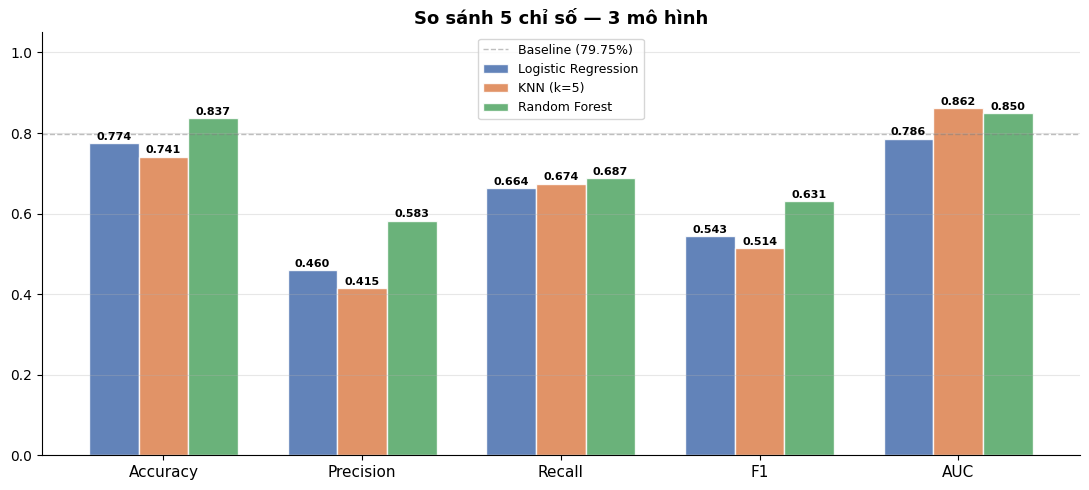

In [3]:
metrics = ['Accuracy', 'Precision', 'Recall', 'F1', 'AUC']
colors  = ['#4C72B0', '#DD8452', '#55A868']
models  = results['Model'].tolist()
x = np.arange(len(metrics))
w = 0.25

fig, ax = plt.subplots(figsize=(11, 5))
for i, (model, color) in enumerate(zip(models, colors)):
    vals = [results.loc[i, m] for m in metrics]
    bars = ax.bar(x + i*w, vals, w, label=model, color=color, alpha=0.88, edgecolor='white')
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.008,
                f'{val:.3f}', ha='center', fontsize=8, fontweight='bold')

ax.axhline(0.7975, color='gray', linestyle='--', alpha=0.5, linewidth=1, label='Baseline (79.75%)')
ax.set_xticks(x + w); ax.set_xticklabels(metrics, fontsize=11)
ax.set_ylim(0, 1.05)
ax.set_title('So sánh 5 chỉ số — 3 mô hình', fontsize=13, fontweight='bold')
ax.legend(fontsize=9); ax.grid(axis='y', alpha=0.3)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('comparison_bar.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Confusion Matrix 3 mô hình

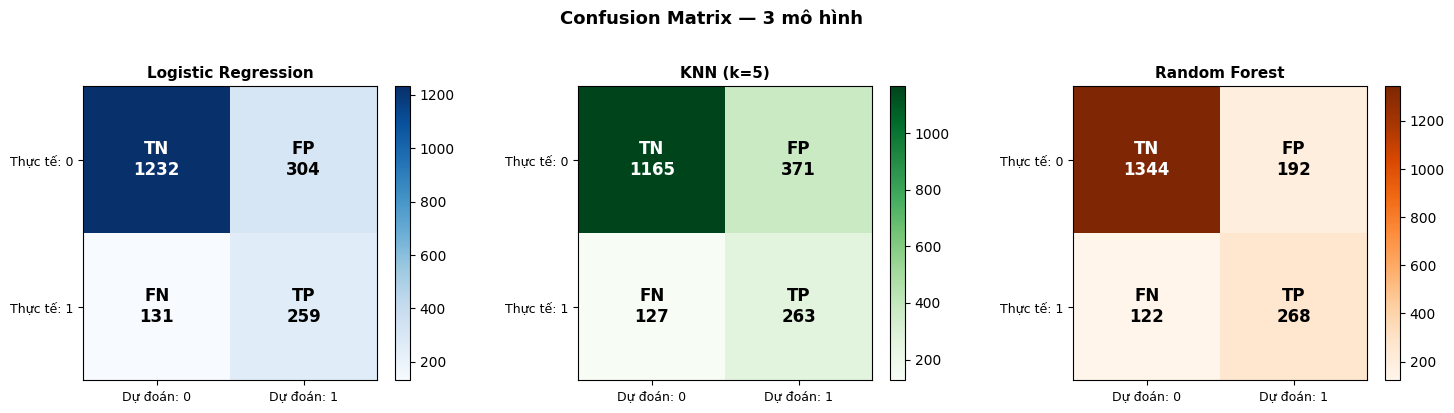

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
cmaps = ['Blues', 'Greens', 'Oranges']
label_map = {(0,0):'TN', (0,1):'FP', (1,0):'FN', (1,1):'TP'}

for ax, (_, row), cmap in zip(axes, results.iterrows(), cmaps):
    cm = np.array([[row['TN'], row['FP']], [row['FN'], row['TP']]])
    im = ax.imshow(cm, cmap=cmap)
    plt.colorbar(im, ax=ax, fraction=0.046)
    thresh = cm.max() / 2
    for i in range(2):
        for j in range(2):
            ax.text(j, i, f"{label_map[(i,j)]}\n{cm[i,j]}",
                    ha='center', va='center', fontsize=12, fontweight='bold',
                    color='white' if cm[i,j] > thresh else 'black')
    ax.set_xticks([0,1]); ax.set_xticklabels(['Dự đoán: 0', 'Dự đoán: 1'], fontsize=9)
    ax.set_yticks([0,1]); ax.set_yticklabels(['Thực tế: 0', 'Thực tế: 1'], fontsize=9)
    ax.set_title(row['Model'], fontsize=11, fontweight='bold')

plt.suptitle('Confusion Matrix — 3 mô hình', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('comparison_cm.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Nhận xét

In [ ]:
print('='*55)
print('             NHẬN XÉT TỔNG HỢP')
print('='*55)
print('''
Random Forest: tốt nhất toàn diện
  - F1=0.63, AUC=0.85, Accuracy=83.7%
  - FP=192 (ít báo động giả nhất)
  - FN=122 (bỏ sót ít churn nhất)

Logistic Regression: trung bình
  - F1=0.54, AUC=0.79
  - Dễ giải thích nhất (có feature importance)

KNN (k=5): yếu nhất về F1
  - F1=0.51, Accuracy<baseline (74%<79.75%)
  - AUC=0.86 cao nhất — khả năng xếp hạng tốt
    nhưng ngưỡng 0.5 chưa tối ưu
  - FP=371 cao nhất — nhiều báo động giả nhất
''')
print('='*55)
print('  Mô hình tốt nhất: Random Forest')
print('='*55)

             NHẬN XÉT TỔNG HỢP

Random Forest: tốt nhất toàn diện
  - F1=0.63, AUC=0.85, Accuracy=83.7%
  - FP=192 (ít báo động giả nhất)
  - FN=122 (bỏ sót ít churn nhất)

Logistic Regression: trung bình
  - F1=0.54, AUC=0.79
  - Dễ giải thích nhất (có feature importance)

KNN (k=5): yếu nhất về F1
  - F1=0.51, Accuracy<baseline (74%<79.75%)
  - AUC=0.86 cao nhất — khả năng xếp hạng tốt
    nhưng ngưỡng 0.5 chưa tối ưu
  - FP=371 cao nhất — nhiều báo động giả nhất

  🏆 Mô hình tốt nhất: Custom Random Forest
